# Module 3 — RFM Segmentation

**Platform:** REES46 Open CDP — anonymous multi-category e-commerce retailer, Kazakhstan / CIS market. 2,064,899 users with at least one purchase (Oct 2019 – Apr 2020).

**Where this fits in the project:** Module 1 (Funnel Analysis) showed platform-wide conversion sits around 6%. This module asks a sharper question about the ~2.06M people who *do* convert: who actually drives the business? RFM (Recency, Frequency, Monetary) segmentation splits purchasing customers into 6 behavioural groups based on how recently they bought, how often, and how much they spent — each dimension scored 1–5 via `NTILE(5)` in BigQuery, then combined into a segment label (`sql/03_rfm_segmentation.sql`). The resulting scores are persisted as `rees46.rfm_segments`, which Module 4 (Cohort Retention) also depends on.

**Business question:** Who are the best customers, and how concentrated is revenue among them?

**Segment definitions (from the SQL `CASE` logic, 5 = best on each dimension):**
- **Champion** — recent, frequent, high-spend (R≥4, F≥4, M≥4)
- **Loyal** — recent-ish and frequent (R≥3, F≥3) — the backbone, not necessarily top spenders
- **At Risk** — used to buy frequently but haven't purchased recently (R≤2, F≥3)
- **Recent but Infrequent** — bought recently but only once or twice (R≥4, F≤2)
- **Lost** — lowest recency and frequency (R=1, F=1)
- **Others** — everyone who doesn't fit the above patterns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Design tokens — dataviz palette.md (reference instance), same tokens used across the project's notebooks
C_SURFACE   = '#fcfcfb'
C_PRIMARY   = '#0b0b0b'
C_SECONDARY = '#52514e'
C_MUTED     = '#898781'
C_GRID      = '#e1e0d9'
C_AXIS      = '#c3c2b7'
C_S1        = '#2a78d6'   # blue — slot 1, % of users / Champion emphasis
C_S2        = '#1baf7a'   # aqua — slot 2, % of revenue

plt.rcParams.update({
    'figure.facecolor':  C_SURFACE,
    'axes.facecolor':    C_SURFACE,
    'axes.edgecolor':    C_AXIS,
    'axes.linewidth':    0.8,
    'grid.color':        C_GRID,
    'grid.linewidth':    0.5,
    'text.color':        C_PRIMARY,
    'axes.labelcolor':   C_SECONDARY,
    'xtick.color':       C_MUTED,
    'ytick.color':       C_MUTED,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

print('Setup complete.')

Setup complete.


---
## 1 — Revenue Concentration by Segment (Pareto view)

Each segment's share of total purchasing users vs. its share of total platform revenue. The gap between the two bars *is* the story — a segment capturing far more revenue than its population share is where the business's actual value lives.

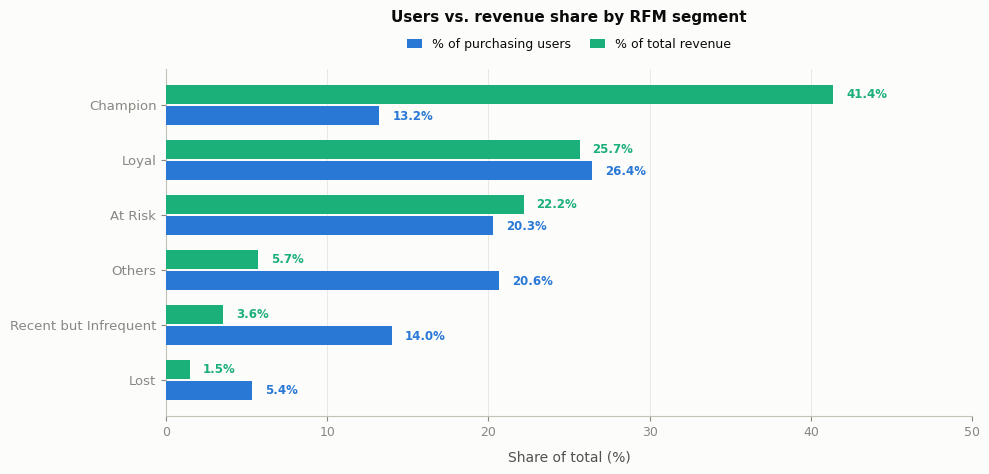

Saved: 03_fig1_segment_pareto.png

Champions: 13.2% of purchasing users generate 41.4% of all platform revenue.
Loyal + At Risk together add another 46.7% of users but only 47.8% of revenue —
roughly proportional. Others + Recent + Lost (40.0% of users) generate just 10.8%.


In [2]:
# Query 2 results — (segment, pct_of_users, pct_of_revenue), sorted by revenue share desc
segment_data = [
    ('Champion',              13.23, 41.40),
    ('Loyal',                 26.45, 25.66),
    ('At Risk',               20.31, 22.18),
    ('Others',                20.64,  5.72),
    ('Recent but Infrequent', 14.00,  3.56),
    ('Lost',                  5.36,  1.48),
]

# Reversed so the largest revenue-share segment (Champion) plots at the top
plot_data = list(reversed(segment_data))
labels    = [d[0] for d in plot_data]
users_pct = [d[1] for d in plot_data]
rev_pct   = [d[2] for d in plot_data]

y = np.arange(len(labels))
bar_h = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(C_SURFACE)

ax.barh(y - bar_h/2 - 0.02, users_pct, height=bar_h, color=C_S1,
        label='% of purchasing users', linewidth=0, zorder=3)
ax.barh(y + bar_h/2 + 0.02, rev_pct, height=bar_h, color=C_S2,
        label='% of total revenue', linewidth=0, zorder=3)

# Direct value labels at each bar's tip
for i in range(len(labels)):
    ax.text(users_pct[i] + 0.8, y[i] - bar_h/2 - 0.02, f'{users_pct[i]:.1f}%',
            va='center', ha='left', fontsize=8.5, fontweight='bold', color=C_S1)
    ax.text(rev_pct[i] + 0.8, y[i] + bar_h/2 + 0.02, f'{rev_pct[i]:.1f}%',
            va='center', ha='left', fontsize=8.5, fontweight='bold', color=C_S2)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9.5)
ax.set_xlabel('Share of total (%)', labelpad=8)
ax.set_title('Users vs. revenue share by RFM segment', fontsize=11,
             fontweight='bold', pad=34, color=C_PRIMARY)
ax.set_xlim(0, 50)
ax.grid(axis='x', zorder=1)

# Legend placed above the axes so it never overlaps the top bar
ax.legend(fontsize=9, framealpha=0, loc='lower center',
          bbox_to_anchor=(0.5, 1.02), ncol=2, handlelength=1.2, columnspacing=1.5)

plt.tight_layout()
plt.subplots_adjust(top=0.82)
plt.savefig('03_fig1_segment_pareto.png', dpi=150, bbox_inches='tight', facecolor=C_SURFACE)
plt.show()
print('Saved: 03_fig1_segment_pareto.png')
print()
print('Champions: 13.2% of purchasing users generate 41.4% of all platform revenue.')
print('Loyal + At Risk together add another 46.7% of users but only 47.8% of revenue —')
print('roughly proportional. Others + Recent + Lost (40.0% of users) generate just 10.8%.')

---
## 2 — Monetary Distribution by Segment

How much do customers in each segment actually spend (lifetime, cumulative across all purchases)? Distributions are heavily right-skewed — a handful of extreme spenders pull the mean far above the median — so the x-axis uses a **log scale**.

**Reading the box:** the box spans P25–P75, the line inside is the median, the whisker extends to P90. A true minimum wasn't queried, so the lower whisker is collapsed to P25 — treat the box's left edge as the practical floor, not the theoretical one. The dot beyond each box is the segment's maximum lifetime spend.

**Champion is highlighted** — it's the segment the business question is really about; the rest are shown in gray for context.

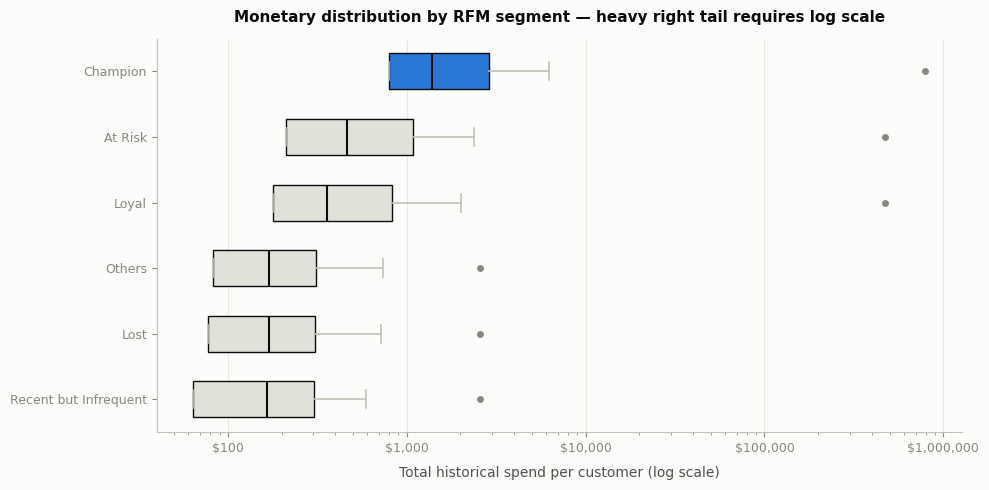

Saved: 03_fig2_monetary_boxplot.png

Champion: median $1,385 vs mean $3,118 vs max $790,121 — a small number of
ultra-high spenders pull the average far above the typical Champion.

Others / Lost / Recent but Infrequent all cap out at exactly $2,574.07 — the same
platform price ceiling found in Module 6 (Anomaly Detection). These are largely
one-purchase customers whose single transaction hit the platform price cap.

At Risk median ($465) and mean ($1,088) exceed Loyal ($361 / $967) — At Risk users
were bigger spenders before going quiet, not just frequent ones. High-value win-back target.


In [3]:
# Query 3 results — (segment, p25, median, p75, p90, max), sorted ascending by median
# so the highest-spend segment (Champion) plots at the top
monetary_data = [
    ('Recent but Infrequent', 64.33, 166.77, 302.08,  591.78,    2574.07),
    ('Lost',                  77.22, 169.35, 308.86,  719.68,    2574.07),
    ('Others',                82.33, 170.15, 311.08,  733.30,    2574.07),
    ('Loyal',                180.07, 361.06, 830.60, 2002.10,  474648.46),
    ('At Risk',              211.68, 465.34,1081.29, 2366.60,  473119.39),
    ('Champion',             792.74,1384.98,2869.93, 6210.49,  790120.94),
]

box_labels = [d[0] for d in monetary_data]
stats = []
for seg, p25, median, p75, p90, mx in monetary_data:
    stats.append({
        'label':   seg,
        'whislo':  p25,   # no true minimum queried — lower whisker collapses to P25
        'q1':      p25,
        'med':     median,
        'q3':      p75,
        'whishi':  p90,
        'fliers':  [mx],
        'mean':    None,
    })

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(C_SURFACE)

bp = ax.bxp(stats, vert=False, patch_artist=True, widths=0.55,
            boxprops=dict(linewidth=1, edgecolor=C_PRIMARY),
            medianprops=dict(color=C_PRIMARY, linewidth=1.5),
            whiskerprops=dict(color=C_AXIS, linewidth=1.2),
            capprops=dict(color=C_AXIS, linewidth=1.2),
            flierprops=dict(marker='o', markersize=6, markerfacecolor=C_MUTED,
                             markeredgecolor=C_SURFACE, markeredgewidth=1))

# Emphasis: Champion in accent blue, the rest in neutral gray
for i, box in enumerate(bp['boxes']):
    box.set_facecolor(C_S1 if box_labels[i] == 'Champion' else C_GRID)

ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'${x:,.0f}' if x >= 1 else f'${x:.2f}'))
ax.set_xlabel('Total historical spend per customer (log scale)', labelpad=8)
ax.set_title('Monetary distribution by RFM segment — heavy right tail requires log scale',
             fontsize=11, fontweight='bold', pad=12, color=C_PRIMARY)
ax.grid(axis='x', which='major', zorder=1)

plt.tight_layout()
plt.savefig('03_fig2_monetary_boxplot.png', dpi=150, bbox_inches='tight', facecolor=C_SURFACE)
plt.show()
print('Saved: 03_fig2_monetary_boxplot.png')
print()
print('Champion: median $1,385 vs mean $3,118 vs max $790,121 — a small number of')
print('ultra-high spenders pull the average far above the typical Champion.')
print()
print('Others / Lost / Recent but Infrequent all cap out at exactly $2,574.07 — the same')
print('platform price ceiling found in Module 6 (Anomaly Detection). These are largely')
print('one-purchase customers whose single transaction hit the platform price cap.')
print()
print('At Risk median ($465) and mean ($1,088) exceed Loyal ($361 / $967) — At Risk users')
print('were bigger spenders before going quiet, not just frequent ones. High-value win-back target.')

---
## Summary of Findings

| Segment | % Users | % Revenue | Avg Recency | Avg Frequency | Avg Monetary |
|---|---|---|---|---|---|
| Champion | 13.23% | **41.40%** | 27.8 days | 9.24 | `$3,117.85` |
| Loyal | 26.45% | 25.66% | 54.7 days | 3.69 | `$966.62` |
| At Risk | 20.31% | 22.18% | 152.6 days | 3.53 | `$1,087.71` |
| Others | 20.64% | 5.72% | 130.2 days | 1.00 | `$276.00` |
| Recent but Infrequent | 14.00% | 3.56% | 27.3 days | 1.00 | `$253.60` |
| Lost | 5.36% | 1.48% | 182.4 days | 1.00 | `$274.59` |

**1. Champions are 13% of users but 41% of revenue — a textbook, extreme Pareto skew.**  
Retention and service investment for this segment has the highest revenue-per-dollar payoff on the platform.

**2. At Risk is the highest-value win-back opportunity.**  
419,470 users, `$456M` in historical revenue, averaging 3.53 past purchases before going quiet for ~153 days. Their median spend (`$465`) and mean (`$1,088`) exceed Loyal's — these were good customers, not casual browsers. Reactivating even 20% of this segment is high-ROI relative to acquiring new users.

**3. Loyal is the backbone — largest segment, strong revenue share, room to grow into Champion.**  
26.45% of users generate 25.66% of revenue — nearly proportional, unlike the extreme skew of Champions. Converting a slice of Loyal into Champion (via frequency or spend nudges) is a realistic lever.

**4. Recent but Infrequent is a second-purchase conversion opportunity, not a lost cause.**  
289,189 users bought within the last 27.3 days on average but only once. They are engaged *right now* — the single highest-leverage growth action for this group is prompting a second purchase before they drift into Lost.

**5. Others + Recent but Infrequent + Lost = 40% of users but only 10.8% of revenue.**  
Low priority for retention spend. Budget is better spent on Champion retention and At Risk win-back.

**6. The monetary distribution is heavily right-skewed in every segment — median, not mean, is the representative figure for dashboards.**  
Champion's mean (`$3,118`) is more than double its median (`$1,385`); the gap is driven by a small number of extreme spenders (P90 = `$6,210`, max = `$790,121`).

**7. The `$2,574.07` platform price cap (first identified in Module 6) reappears here.**  
Others, Lost, and Recent but Infrequent all show a maximum lifetime spend of exactly `$2,574.07` — these are one-purchase customers whose single transaction happened to hit the platform's price ceiling, not a coincidence across three unrelated segments.